# Quantization and Normalization

In this notebook I will explore the mechanics behind quantization

In [18]:
import os
import sys
import pandas as pd
import json
from IPython.display import display, JSON
import numpy as np
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

sys.path.append("..")
sys.path.append("../code")

import torch

from dataset import PointCloudEmbeddingSequenceDataset

#### Adding Attributes (obj.name = "Said")
- In Python, instances have an internal dictionary (```__dict__```) that stores attributes.
- When you do ```obj.name = "Said"```, Python internally adds an entry to ```obj.__dict__``` like this:
```obj.__dict__["name"] = "Said"```
- When you access ```obj.name```, Python checks obj.__dict__ and returns "Said".

In [19]:
class Saver():
    pass

def construct_json_path(cad_seq_path):
    json_path = cad_seq_path.replace("cad_vec", "cad_json").replace("h5", "json")
    return json_path

def show_json():
    json_path = save.json_path
    with open(json_path, "r") as file:
        data = json.load(file)
    display(JSON(data))
    return data

def show_sample(idx, dataset):
    pc, lat_rep, cad_seq = dataset[idx]
    pc_path = dataset.get_cad_seq_path(idx)
    
    seq_length = list(cad_seq[:, 0]).index(3) + 3
    commands = cad_seq[:seq_length, 0]
    arguments = cad_seq[:seq_length,1:]

    print("Commands:   ", commands.tolist())
    print("# of Loops: ", commands.tolist().count(4))
    command_list = torch.repeat_interleave(commands, 16).tolist()
    arg_list = []
    for command_args in arguments:
        arg_list += command_args.tolist()
                
    filtered_lists = [[x for x, trgt_arg in zip(lst, arg_list) if trgt_arg != -1] for lst in [command_list, arg_list]]
    command_list, arg_list = filtered_lists

    print("CAD-sequence path: ", pc_path)
    json_path = construct_json_path(pc_path)
    save.json_path = json_path
    print("Json path: ", json_path)
    df = pd.DataFrame(list(zip(command_list, arg_list)), columns=['command', 'argument'])
    return df

In [20]:
dataset = PointCloudEmbeddingSequenceDataset("../data", 'test')
print(f"Dataset contains {len(dataset)} samples.")
save = Saver()

Dataset contains 8038 samples.


In [21]:
idx = 3

Below is a target vectorized CAD-sequence. In the following cells I will scrutinize the transformation from json data to this format.

In [22]:
show_sample(idx, dataset)

Commands:    [4, 1, 0, 1, 0, 4, 2, 4, 2, 5, 3, 3, 3]
# of Loops:  3
CAD-sequence path:  ../data/cad_vec/0023/00239323.h5
Json path:  ../data/cad_json/0023/00239323.json


,command,argument
0,1,176
1,1,128
2,1,128
3,1,1
4,0,176
5,0,199
6,1,128
7,1,199
8,1,128
9,1,1


In [23]:
json_data = show_json()

<IPython.core.display.JSON object>

The json file contains three dicts:
- **entities**: Sketches and Extrusion
    - Sketch:
        - Transform object with origin and x-, y- and z-axis vectors.
        - Profile object with all curves it is made out of. Each curve can be Arc, Circle or Line and the respective args are listed.
    - Extrusion:
         - References the Sketch under profiles and the extrusion arguments extent one, extent two, operation and extent type
- **properties**: Bounding box
    - Contains maximum and minimum point
- **sequence**: Describes the sequence of sketch and extrude operations by referencing the entities

The pipeline from json to vector representation comprises the normalization and quantization. Lets look at this now.

1. ```json2vec.py```: Loads the json files and creates a ```CADSequence``` object per json file
    - ```CADSequence``` has a staticmethod to create the class from a dict which is the json file. All ```from_dict()``` methods will be implemented as ```get_()``` methods here, but the class definition will stay the same.
    - ```CADSequence``` searches for the all the Extrude operations in the sequence, creates an ```Extrude``` object for each, and concatenates them in a list.
2. 

In [24]:
from models.DeepCAD.cadlib.extrude import CADSequence, Extrude
from models.DeepCAD.cadlib.sketch import Profile, Loop
from models.DeepCAD.cadlib.curves import Line, Arc, Circle

In [25]:
def get_CADSequence(all_stat):
    seq = []
    print("First we iterate thorough the sequence dict of the json and for each 'Extude_Feature' we create an 'Extrude' object.\n")
    for item in json_data["sequence"]:
        print(item)
        if item["type"] == "ExtrudeFeature":
            extrude_ops = get_Extrude(all_stat, item["entity"])

In [26]:
def get_Extrude(all_stat, extrude_id, sketch_dim=256):
    
    extrude_entity = all_stat["entities"][extrude_id]
    assert extrude_entity["start_extent"]["type"] == "ProfilePlaneStartDefinition"
    all_skets = []
    n = len(extrude_entity["profiles"])

    print(f"\nTo create the 'Extrude' object for {extrude_id} we calculate the number of profiles it contains: {n}\n")

    for i in range(len(extrude_entity["profiles"])):
        sket_id, profile_id = extrude_entity["profiles"][i]["sketch"], extrude_entity["profiles"][i]["profile"]
        print(f"We then extract the sketch id of the profile: {sket_id}, and the profile id: {profile_id}\n")
        sket_entity = all_stat["entities"][sket_id]
        print(f"Then we create a 'Profile' class by providing the profile id {profile_id} to the Profile constructor.\n")
        
        sket_profile = get_Profile(sket_entity["profiles"][profile_id])
        print(f"\nAfter we created the profile we have to provide a 'CoordSystem' class as well. The information is stored in the "
              f"sket_entity {sket_id} under 'transform'.")
        sket_plane = get_CoordSystem(sket_entity["transform"])

In [39]:
def get_CoordSystem(stat):

    origin = np.array([stat["origin"]["x"], stat["origin"]["y"], stat["origin"]["z"]])
    normal_3d = np.array([stat["z_axis"]["x"], stat["z_axis"]["y"], stat["z_axis"]["z"]])
    x_axis_3d = np.array([stat["x_axis"]["x"], stat["x_axis"]["y"], stat["x_axis"]["z"]])
    y_axis_3d = np.array([stat["y_axis"]["x"], stat["y_axis"]["y"], stat["y_axis"]["z"]])
    print(f"\nThis is the original CoordSystem:\n"
          f"origin: {origin}\n"
          f"x     : {x_axis_3d}\n"
          f"y     : {y_axis_3d}\n"
          f"normal: {normal_3d}\n")
    plot_coordinate_system(origin, x_axis_3d, y_axis_3d, normal_3d)
    theta, phi, gamma = polar_parameterization(normal_3d, x_axis_3d)
    return CoordSystem(origin, theta, phi, gamma, y_axis=cartesian2polar(y_axis_3d))

In [40]:
%matplotlib inline
def plot_coordinate_system(origin, x_axis, y_axis, z_axis):
    fig = plt.figure()
    ax = fig.add_subplot(111, projection='3d')

    ax.quiver(*origin, *x_axis, color='r', label="X-axis")
    ax.quiver(*origin, *y_axis, color='g', label="Y-axis")
    ax.quiver(*origin, *z_axis, color='b', label="Z-axis")

    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel('Z')
    ax.legend()
    ax.set_title("3D Coordinate System")

    max_range = np.max(np.abs([*origin, *x_axis, *y_axis, *z_axis])) + 0.5
    ax.set_xlim([-max_range, max_range])
    ax.set_ylim([-max_range, max_range])
    ax.set_zlim([-max_range, max_range])

    plt.show()

In [ ]:
def polar_parameterization(normal_3d, x_axis_3d):
    """represent a coordinate system by its rotation from the standard 3D coordinate system

    Args:
        normal_3d (np.array): unit vector for normal direction (z-axis)
        x_axis_3d (np.array): unit vector for x-axis

    Returns:
        theta, phi, gamma: axis-angle rotation 
    """
    normal_polar = cartesian2polar(normal_3d)
    theta = normal_polar[0]
    phi = normal_polar[1]

    ref_x = rotate_by_z(rotate_by_y(np.array([1, 0, 0]), theta), phi)

    gamma = np.arccos(np.dot(x_axis_3d, ref_x).round(6))
    if np.dot(np.cross(ref_x, x_axis_3d), normal_3d) < 0:
        gamma = -gamma
    return theta, phi, gamma

In [41]:
def get_Profile(stat):
    print(f"A 'Profile' class is a list of 'Loop' classes, therefore to construct a 'Profile' we have to sequentially "
          f"create 'Loop' objects defined in the json data. Each sketch is made up of a 'Profile' for which we provided the id. "
          f"Under the profile id we can see the loops. Each 'Loop' has a 'is_outer' bool and a number of profile curves. These "
          f"will be provided to the 'Curve' constructor.\n")
    print(f"Number of loops in this Profile: {len(stat['loops'])}")
    all_loops = [get_Loop(item) for item in stat['loops']]
    print("\nFinally we created all Loops: ")
    for a in all_loops:
        print(a)
    all_loops = reorder_loops(all_loops)
    return Profile(all_loops, reorder=False) # in the original code reorder is set to True, here fore
    # documentation purposes the reorder method will be implemented outside of the class

In [42]:
def reorder_loops(children):
    if len(children) <= 1:
        print("\nIf the 'Profile' consists of only one Loop, no reordering is necessary") 
        return children

    print(f"\nTo order the Loops they are sorted according to their x_min bbox values, breaking ties using their y_min value. "
          f"Then the Loops are sorted starting with the Loops that has the lowest x_min and y_min values.")
    all_loops_bbox_min = np.stack([loop.bbox[0] for loop in children], axis=0).round(6)
    ind = np.lexsort(all_loops_bbox_min.transpose()[[1, 0]])
    children = [children[i] for i in ind]
    return children
    

In [43]:
def get_Loop(stat):
    print(f"\nThe 'Loop' class consists of a list of 'Curve' classes. The 'Loop' constructor iterates through the "
          f"curve information provided in the json data.")
    for i, item in enumerate(stat['profile_curves']):
        print(i, item)

    all_curves = [get_Curve(item) for item in stat['profile_curves']]
    all_curves = reorder_curves(all_curves)
    this_loop = Loop(all_curves, reorder=False)
    # in the original code reorder is set to True, here fore
    # documentation purposes the reorder method will be implemented outside of the class
    this_loop.is_outer = stat['is_outer']
    return this_loop

In [44]:
def reorder_curves(children):
    """reorder by starting left most and counter-clockwise"""
    if len(children) <= 1:
        print("\nIf the 'Loop' consists of only one Curve, no reordering is necessary") 
        return children

    start_curve_idx = -1
    sx, sy = 10000, 10000

    # correct start-end point order
    print("\nREORDERING CURVES\nWhen reordering curves the goal is to have them starting left most and counter-clockwise.")
    print(f"\nIn reordering the curves, first we check for the first two curves if the start point "
              f"of the first and second Curve is the same ({np.allclose(children[0].start_point, children[1].start_point)}) "
              f"or if the start point of the first and the end point of the second Curve is the same "
              f"({np.allclose(children[0].start_point, children[1].end_point)}). If yes, then the first curve get reversed, i.e. "
              f"for 'Line' and 'Arc' the start and end point are switched.")
    if np.allclose(children[0].start_point, children[1].start_point) or \
        np.allclose(children[0].start_point, children[1].end_point):
        children[0].reverse()

    # correct start-end point order and find left-most point
    print("\nNow we iterate through the curves and everytime two consecutive curves have the same end point, reverse the second curve."
          " Then we find the left most point of all curves.")
    for i, curve in enumerate(children):
        if i < len(children) - 1 and np.allclose(curve.end_point, children[i + 1].end_point):
            children[i + 1].reverse()
        if round(curve.start_point[0], 6) < round(sx, 6) or \
                (round(curve.start_point[0], 6) == round(sx, 6) and round(curve.start_point[1], 6) < round(sy, 6)):
            start_curve_idx = i
            sx, sy = curve.start_point

    children = children[start_curve_idx:] + children[:start_curve_idx]

    # ensure mostly counter-clock wise
    if isinstance(children[0], Circle) or isinstance(children[-1], Circle): # FIXME: hard-coded
        return children
    start_vec = children[0].direction()
    end_vec = children[-1].direction(from_start=False)
    if np.cross(end_vec, start_vec) <= 0:
        for curve in children:
            curve.reverse()
        children.reverse()
    return children

In [45]:
def get_Curve(stat):
    print(f"\nDepending on the type of 'Curve' (Arc, Line, Circle) call the respective constructor.\n")
    print(f"Type: {stat['type']}")
    if stat['type'] == "Line3D":
        return get_Line(stat)
    elif stat['type'] == "Circle3D":
        return get_Circle(stat)
    elif stat['type'] == "Arc3D":
        return get_Arc(stat)
    else:
        raise NotImplementedError("curve type not supported yet: {}".format(stat['type']))

In [46]:
def get_Line(stat):
    assert stat['type'] == "Line3D"
    print(f"To create a 'Line' object, we extract the start and endpoint of the line as numpy arrays.")
    start_point = np.array([stat['start_point']['x'],
                            stat['start_point']['y']])
    end_point = np.array([stat['end_point']['x'],
                          stat['end_point']['y']])
    print(f"Start point: {start_point}\nEnd point: {end_point}")
    return Line(start_point, end_point)

def get_Circle(stat):
    print(f"To create a 'Circle' object, we extract the center point, the radius and the normal.")
    assert stat['type'] == "Circle3D"
    center = np.array([stat['center_point']['x'],
                       stat['center_point']['y']])
    radius = stat['radius']
    normal = np.array([stat['normal']['x'],
                       stat['normal']['y'],
                       stat['normal']['z']])
    print(f"Center: {center}, Radius: {radius}, Normal: {normal}")
    return Circle(center, radius, normal)

def get_Arc(stat):
    print(f"To create a 'Arc' object, we extract the start-, center- and end-point, the radius, the normal, "
          f"the start- and eng-angle and the reference vector.")
    assert stat['type'] == "Arc3D"
    start_point = np.array([stat['start_point']['x'],
                            stat['start_point']['y']])
    end_point = np.array([stat['end_point']['x'],
                          stat['end_point']['y']])
    center = np.array([stat['center_point']['x'],
                       stat['center_point']['y']])
    radius = stat['radius']
    normal = np.array([stat['normal']['x'],
                       stat['normal']['y'],
                       stat['normal']['z']])
    start_angle = stat['start_angle']
    end_angle = stat['end_angle']
    ref_vec = np.array([stat['reference_vector']['x'],
                        stat['reference_vector']['y']])
    print(f"Start point: {start_point}\nEnd point: {end_point}\nCenter: {center}\nRadius: {radius}\nNormal: {normal}\n"
          f"Start angle: {start_angle}\nEnd angle: {end_angle}\nReference vector: {ref_vec}")
    return Arc(start_point, end_point, center, radius, normal, start_angle, end_angle, ref_vec)

First we iterate thorough the sequence dict of the json and for each 'Extude_Feature' we create an 'Extrude' object.

{'index': 0, 'type': 'Sketch', 'entity': 'FZju8KWrsx7pSQP_0'}
{'index': 1, 'type': 'ExtrudeFeature', 'entity': 'FK8QzQJB7rehzNa_0'}

To create the 'Extrude' object for FK8QzQJB7rehzNa_0 we calculate the number of profiles it contains: 1

We then extract the sketch id of the profile: FZju8KWrsx7pSQP_0, and the profile id: JGK

Then we create a 'Profile' class by providing the profile id JGK to the Profile constructor.

A 'Profile' class is a list of 'Loop' classes, therefore to construct a 'Profile' we have to sequentially create 'Loop' objects defined in the json data. Each sketch is made up of a 'Profile' for which we provided the id. Under the profile id we can see the loops. Each 'Loop' has a 'is_outer' bool and a number of profile curves. These will be provided to the 'Curve' constructor.

Number of loops in this Profile: 3

The 'Loop' class consists of a list of 'C

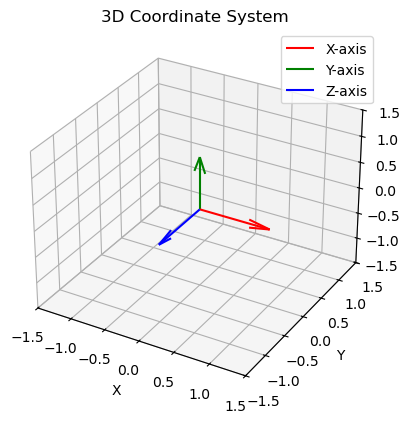

NameError: name 'polar_parameterization' is not defined

In [47]:
get_CADSequence(json_data)

In [48]:
lol = [1,2,3,4,5,6]

In [18]:
arsch = lol[:3] + lol[3:]

In [19]:
arsch

[1, 2, 3, 4, 5, 6]

In [92]:
start_point = np.array([1,1])
print(start_point.shape)
end_point = np.array([3,3])
points = np.stack([start_point, end_point], axis=0)

(2,)


In [93]:
print(points, points.shape)

[[1 1]
 [3 3]] (2, 2)


In [97]:
o = np.stack([np.min(points, axis=0), np.max(points, axis=0)])
o

array([[1, 1],
       [3, 3]])

In [98]:
o[0]

array([1, 1])

In [116]:
mins = np.array([[1,1], [3,4], [5,2], [3,3]])
mins

array([[1, 1],
       [3, 4],
       [5, 2],
       [3, 3]])

In [117]:
mins.transpose()

array([[1, 3, 5, 3],
       [1, 4, 2, 3]])

In [118]:
mins.transpose()[[1,0]]

array([[1, 4, 2, 3],
       [1, 3, 5, 3]])

In [119]:
np.lexsort(mins.transpose()[[1, 0]])

array([0, 3, 1, 2])

In [103]:
ind

array([2, 0, 3, 1])

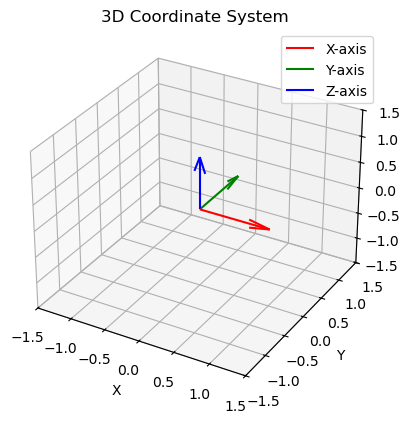

In [176]:




# Example usage with standard basis vectors
origin = np.array([0, 0, 0])
x_axis = np.array([1, 0, 0])
y_axis = np.array([0, 1, 0])
z_axis = np.array([0, 0, 1])




In [ ]:
c